In [1]:
import numpy as np
import pandas as pd
import pickle
import plotly.graph_objects as go
import plotly.io as pio

from nteprsm import utils 
from settings import ROOT_DIR

def map_name2code(datahandler, column_name, code_column_name, invert=False):
    """Retrieves a dictionary mapping names to codes from specified columns."""
    name2code = dict(datahandler.model_data.groupby(column_name)[code_column_name].first())
    if invert:
        name2code = {v: k for k, v in name2code.items()}
    return name2code

def extract_time_effect(datahandler: "utils.DataHandler", fit: "stan fit object") -> pd.DataFrame:
    """Extract and format the time effect from a fitted model object."""
    raing_event2doy = datahandler.model_data[['adj_time_of_year', 'rating_event_code']].drop_duplicates(
        ).sort_values(by='rating_event_code')
    time_effect = pd.DataFrame(
        fit.stan_variable("time_effect").mean(axis=0),
        columns=raing_event2doy['adj_time_of_year'].values
    )
    
    time_effect.index = time_effect.index
    time_effect = time_effect.T.sort_index()
    time_effect.index.name = 'adj_time_of_year'
    return time_effect

/users/2/oboiko/.conda/envs/nteprsm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = ROOT_DIR/'kb2017/nj2/quality.csv'
FIT_OBJECT_PATH = ROOT_DIR/'model_runs/seasonality_nj2_quality/fit_seasonality_nj2_quality.pkl'

df = pd.read_csv(DATA_PATH)
df = df.assign(
    PLT_ID_CODE=pd.Categorical(df["plot_id"]).codes
)
with open(FIT_OBJECT_PATH, 'rb') as file:
    fit = pickle.load(file)
    
datahandler = utils.DataHandler(filepath=DATA_PATH)
datahandler.load_data(raw_data=df)
datahandler.preprocess_data()
datahandler.model_data["entry_name"] = df["entry_name"]

/users/2/oboiko/NTEP/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-06-30 10:53:50,424 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-06-30 10:53:50,438 - NtepRsm - INFO - Data preprocessing completed.


In [3]:
name2code = map_name2code(datahandler,'entry_name','entry_code', invert=True)
print(name2code)

{75: 'A-15-6', 76: 'A-16-17', 73: 'A-16-2', 78: 'A06-8', 71: 'A10-280', 67: 'A11-26', 69: 'A11-38', 1: 'A11-40', 66: 'A12-34', 2: 'A13-1', 64: 'A16-1', 65: 'A16-7', 3: 'A99-2897', 9: 'AKB3128', 10: 'AKB3179', 11: 'AKB3241', 70: 'Acoustic PPG-KB 1131', 15: 'After Midnight', 38: 'Amaze', 42: 'Aviator II', 20: 'BAR PP 71213', 25: 'BAR PP 7236V', 21: 'BAR PP 7309V', 22: 'BAR PP 79366', 26: 'BAR PP 79494', 24: 'BAR PP 7K426', 8: 'Babe', 27: 'Barserati', 23: 'Barvette HGT', 44: 'Blue Devil', 32: 'Blue Gem', 5: 'Blue Knight', 46: 'Bombay', 48: 'Cloud', 39: 'Comanche', 49: 'DLFPS-340/3364', 55: 'DLFPS-340/3438', 58: 'DLFPS-340/3444', 50: 'DLFPS-340/3446', 59: 'DLFPS-340/3455', 53: 'DLFPS-340/3494', 54: 'DLFPS-340/3500', 57: 'DLFPS-340/3548', 56: 'DLFPS-340/3549', 60: 'DLFPS-340/3550', 61: 'DLFPS-340/3551', 62: 'DLFPS-340/3552', 52: 'DLFPS-340/3553', 51: 'DLFPS-340/3556', 83: 'Dublin', 82: 'Electric', 40: 'Finish Line', 41: 'Heartland', 16: 'J-1138', 17: 'J-1319', 18: 'J-2726', 29: 'Jersey', 13

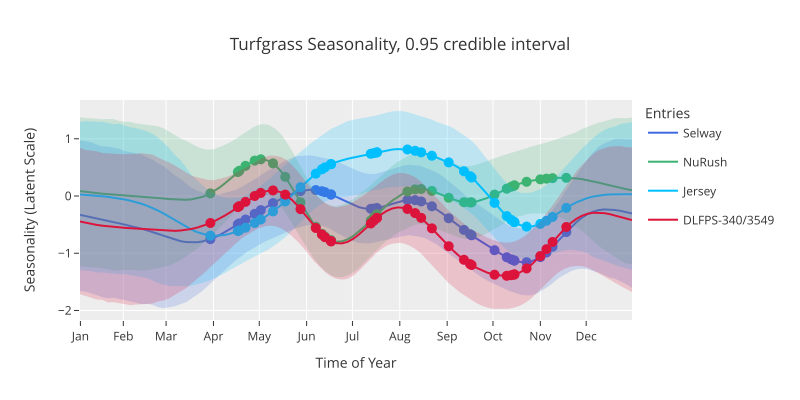

In [4]:
colors = ['royalblue', 'mediumseagreen', 'deepskyblue', 'crimson']
entries = [7, 19, 29, 56]

## params
ci = 0.95  # Credible interval

# Create a single figure
fig = go.Figure()

# time_effect_data_points
data_points = extract_time_effect(datahandler, fit)
data_points_time = data_points.index.values

for i, entry in enumerate(entries):
    entry_name = name2code[entry]
    legend_group = f"Entry {entry_name}"    
    samples = fit.pred_time_effect[:, entry, :]  # Shape: (n_samples, n_time_points)
    
    # Compute statistics
    time_points = np.arange(samples.shape[1])+1  # Time indices
    mean_values = np.mean(samples, axis=0)  # Mean over samples
    lower_bound = np.percentile(samples, 100 * (1 - ci) / 2, axis=0)  # 2.5th percentile
    upper_bound = np.percentile(samples, 100 * (ci + (1 - ci) / 2), axis=0)  # 97.5th percentile

    # Add data point
    fig.add_trace(go.Scatter(
        x=data_points_time*100, y=data_points[entry],
        mode='markers',
        marker=dict(
            symbol='circle',  # Set the marker shape to "X"
            color=colors[i],  # Keep the color
            size=10  # Optionally, set the size of the marker
        ),
        name=f'{entry_name} Mean',
        legendgroup=legend_group,
        showlegend=False,
    ))

    # Add mean line
    fig.add_trace(go.Scatter(
        x=time_points, y=mean_values,
        mode='lines',
        line=dict(color=colors[i], width=2),
        name=f'{entry_name}',
        legendgroup=legend_group,
    ))
    
    # Add 95% Credible Interval (Shaded Region)
    fig.add_trace(go.Scatter(
        x=time_points.tolist() + time_points[::-1].tolist(),
        y=upper_bound.tolist() + lower_bound[::-1].tolist(),
        fill='toself',
        fillcolor=colors[i],
        opacity=0.2,
        line=dict(color='rgba(255,255,255,0)'),
        name=f'{entry_name} 95% CI',
        legendgroup=legend_group,  # Grouping
        showlegend=False,
    ))
    
# Compute correct tick positions based on actual day of the year
days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])  # Non-leap year
cumulative_days = np.cumsum(days_in_month)+1  # Cumulative sum to get end of each month
month_positions = 100*cumulative_days / 365  # Normalize to range 0-100
month_positions[0] += 0.8

# Generate month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig.update_layout(
    xaxis=dict(
        tickmode="array",
        tickvals=month_positions,  # Correctly spaced tick positions
        ticktext=month_labels,  # Month names
        title="Time of Year"
    ),
    yaxis_title="Seasonality (Latent Scale)",
    title=f"Turfgrass Seasonality, {ci} credible interval",
    template="ggplot2",
    legend=dict(title="Entries")
) 

# needed to adjust figure size here with static renderer for plotly
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 400

fig.show(renderer="svg")